In [1]:
import dataclasses
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.visualization
import pandas
import named_arrays as na
import optika
import esis

In [2]:
instrument = esis.flights.f2.optics.design_single(num_distribution=0)

In [3]:
instrument.field.num = 5

2026-07-08 20:05:52 - astropy - WARNING: function 'sqrt' is not known to astropy's Quantity. Will run it anyway, hoping it will treat ndarray subclasses correctly. Please raise an issue at https://github.com/astropy/astropy/issues.


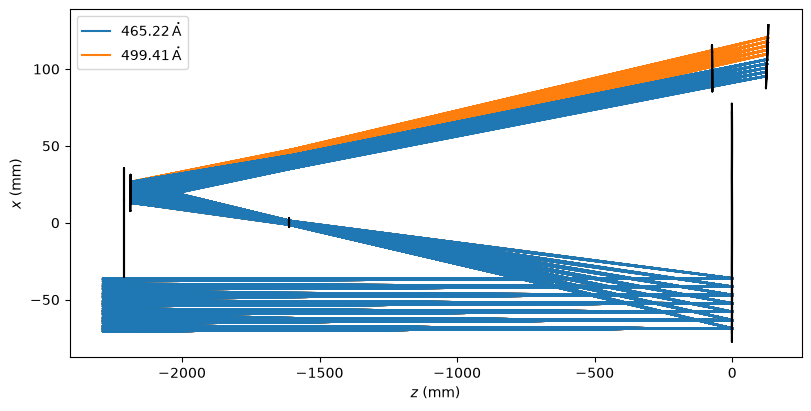

In [4]:
with astropy.visualization.quantity_support():
    fig, ax = plt.subplots(
        figsize=(8, 4),
        constrained_layout=True,
    )
    instrument.system.plot(
        ax=ax,
        components=("z", "x"),
        color="black",
        kwargs_rays=dict(
            color=na.ScalarArray(
                ndarray=np.array(["tab:blue", "tab:orange"]),
                axes="wavelength",
            ),
            label=instrument.wavelength.to_string_array(),
            zorder=-instrument.wavelength.value,
        ),
    )
    ax.set_xlabel(f"$z$ ({ax.get_xlabel()})")
    ax.set_ylabel(f"$x$ ({ax.get_ylabel()})")

    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys())

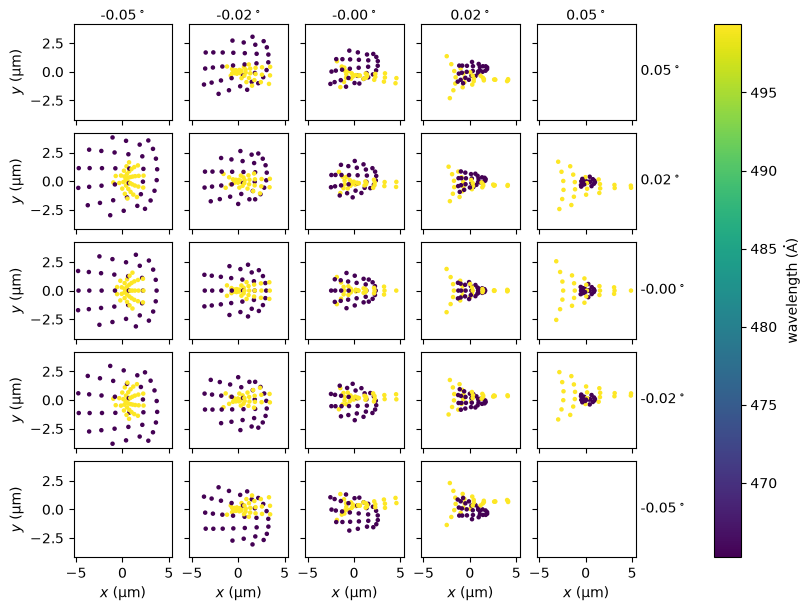

In [5]:
instrument.system.spot_diagram();

In [6]:
position = na.Cartesian2dVectorArray(
    x=na.linspace(0, 80, axis="x", num=11) * u.mm,
    y=0 * u.mm,
)

In [7]:
z = -instrument.primary_mirror.sag(position)

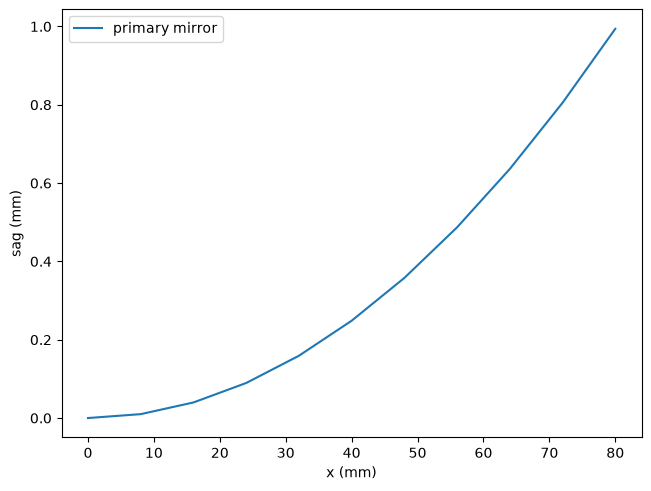

In [8]:
with astropy.visualization.quantity_support():
    fig, ax = plt.subplots(constrained_layout=True)
    na.plt.plot(position.x, z, label="primary mirror")
    ax.set_xlabel(f"x ({ax.get_xlabel()})")
    ax.set_ylabel(f"sag ({ax.get_ylabel()})")
    ax.legend()

In [9]:
print(pandas.DataFrame(np.stack([position.x.ndarray, z.ndarray]).T, columns=["x", "sag"]))

       x       sag
0    0.0  0.000000
1    8.0  0.009940
2   16.0  0.039761
3   24.0  0.089463
4   32.0  0.159046
5   40.0  0.248509
6   48.0  0.357853
7   56.0  0.487078
8   64.0  0.636183
9   72.0  0.805169
10  80.0  0.994036


In [10]:
field = na.Cartesian2dVectorLinearSpace(
    start=-0.99,
    stop=+0.99,
    axis=na.Cartesian2dVectorArray("fx", "fy"),
    num=11,
)

In [11]:
pupil=na.Cartesian2dVectorLinearSpace(
    start=-0.99,
    stop=+0.99,
    axis=na.Cartesian2dVectorArray("px", "py"),
    num=41,
)

In [12]:
instrument_full = esis.flights.f2.optics.design(
    grid=optika.vectors.ObjectVectorArray(
        wavelength=instrument.wavelength,
        field=field,
        pupil=pupil,
    ), 
    num_distribution=0,
)

In [13]:
instrument_full.roll = 22.5 * u.deg

In [14]:
transformation = na.transformations.Cartesian3dRotationY(180 * u.deg)

2026-07-08 20:06:00 - astropy - WARNING: function 'sqrt' is not known to astropy's Quantity. Will run it anyway, hoping it will treat ndarray subclasses correctly. Please raise an issue at https://github.com/astropy/astropy/issues.


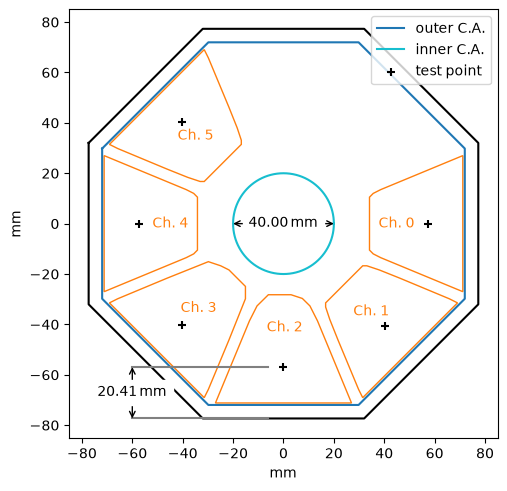

In [15]:
with astropy.visualization.quantity_support():
    fig, ax = plt.subplots(constrained_layout=True)
    instrument_full.schematic_primary(
        ax=ax,
        transformation=transformation,
    )
    ax.set_aspect("equal")
    ax.legend()